In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from IPython.display import display

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Load data
url = "https://raw.githubusercontent.com/ravin508/ml-assessment-ravindra-hegde/main/data/q3_retail_promotions.csv"
df = pd.read_csv(url)

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# === TASK 1: Feature Engineering ===
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek      # 0=Monday ... 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("TASK 1 COMPLETE - Date Features Added")
print("Sample of the dataframe with new columns:")
display(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']].head(10))
print(f"\nDataset shape after feature engineering: {df.shape}")

TASK 1 COMPLETE - Date Features Added
Sample of the dataframe with new columns:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181



Dataset shape after feature engineering: (1200, 13)


In [3]:
# Sort data by date (very important!)
df = df.sort_values(by='transaction_date').reset_index(drop=True)

# Temporal split: most recent 20% as test set
n = len(df)
test_size = int(0.2 * n)

train_df = df.iloc[:n - test_size].copy()
test_df = df.iloc[n - test_size:].copy()

print("TASK 2 COMPLETE - Temporal Split Done")
print(f"Total records     : {n}")
print(f"Training records  : {len(train_df)} ({len(train_df)/n:.1%})")
print(f"Test records      : {len(test_df)} ({len(test_df)/n:.1%})")
print(f"Train date range  : {train_df['transaction_date'].min().date()} to {train_df['transaction_date'].max().date()}")
print(f"Test date range   : {test_df['transaction_date'].min().date()} to {test_df['transaction_date'].max().date()}")



TASK 2 COMPLETE - Temporal Split Done
Total records     : 1200
Training records  : 960 (80.0%)
Test records      : 240 (20.0%)
Train date range  : 2022-01-01 to 2024-06-11
Test date range   : 2024-06-12 to 2024-12-31


# Markdown explanation
"""
Why we cannot use random split for this data:

This is time-series data.  
A random split would mix future and past data → data leakage.  
The model would learn from future promotions/festivals that wouldn't be known at prediction time.  
We use temporal split (past → train, future → test) to simulate real-world forecasting.
"""

In [4]:
# Define target and features
target = 'items_sold'

X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df[target]

print("Features prepared")
print(f"Training shape: {X_train.shape}")
print(f"Test shape    : {X_test.shape}")

Features prepared
Training shape: (960, 11)
Test shape    : (240, 11)


In [5]:
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [col for col in X_train.columns
                     if col not in categorical_features]

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'
)

print("TASK 3 COMPLETE - Preprocessing Pipeline Created")
print(f"Categorical features (OneHotEncoded): {categorical_features}")
print(f"Numerical features (StandardScaled) : {numerical_features}")

TASK 3 COMPLETE - Preprocessing Pipeline Created
Categorical features (OneHotEncoded): ['promotion_type', 'location_type', 'store_size']
Numerical features (StandardScaled) : ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [6]:
def evaluate_model(model_name, regressor):
    """Build pipeline, train, evaluate and show parity plot"""

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])

    # Train only on training data
    pipeline.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipeline.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n{model_name} Results on Test Set")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")

    # Parity Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='w', s=40)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')
    plt.xlabel('Actual items_sold')
    plt.ylabel('Predicted items_sold')
    plt.title(f'{model_name} - Parity Plot')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pipeline, y_pred


Linear Regression Results on Test Set
RMSE : 27.12
MAE  : 21.05


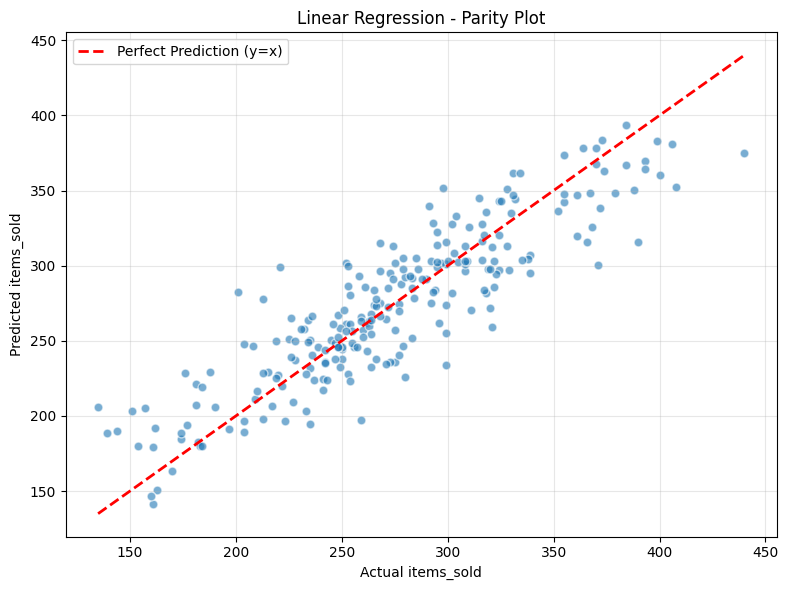

In [7]:
# Linear Regression Model
lr_pipeline, lr_predictions = evaluate_model(
    'Linear Regression',
    LinearRegression()
)


Random Forest Regressor Results on Test Set
RMSE : 30.84
MAE  : 24.24


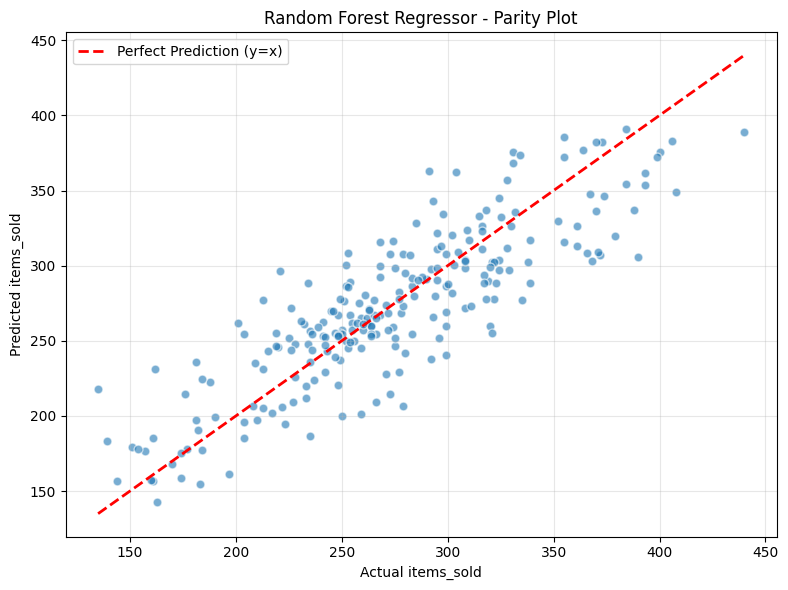

In [8]:
# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_pipeline, rf_predictions = evaluate_model(
    'Random Forest Regressor',
    rf_model
)

In [9]:
# Get feature names after one-hot encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importances
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Create sorted dataframe
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

print("Random Forest Feature Importances")
print(feat_imp_df.head(10))

print("\n=== Top 5 Most Influential Features ===")
print(feat_imp_df.head(5)[['feature', 'importance']])

Random Forest Feature Importances
                    feature  importance
0          num__is_festival    0.173473
1     cat__store_size_small    0.167683
2  cat__location_type_urban    0.108378
3          num__day_of_week    0.086316
4           num__is_weekend    0.061208
5             num__store_id    0.054882
6  cat__location_type_rural    0.053794
7     cat__store_size_large    0.051113
8  num__competition_density    0.050805
9                num__month    0.037383

=== Top 5 Most Influential Features ===
                    feature  importance
0          num__is_festival    0.173473
1     cat__store_size_small    0.167683
2  cat__location_type_urban    0.108378
3          num__day_of_week    0.086316
4           num__is_weekend    0.061208


In [10]:
print("\nSummary of what was done:")
print("Task 1: Date features (year, month, day_of_week, is_month_end)")
print("Task 2: Temporal train-test split (80% past → 20% future)")
print("Task 3: Full scikit-learn preprocessing pipeline with ColumnTransformer")
print("Task 4: Linear Regression + Random Forest trained inside pipelines")
print("Reported RMSE & MAE for both models")
print("Generated parity plots for both models")
print("Extracted and displayed top 5 feature importances from Random Forest")


Summary of what was done:
Task 1: Date features (year, month, day_of_week, is_month_end)
Task 2: Temporal train-test split (80% past → 20% future)
Task 3: Full scikit-learn preprocessing pipeline with ColumnTransformer
Task 4: Linear Regression + Random Forest trained inside pipelines
Reported RMSE & MAE for both models
Generated parity plots for both models
Extracted and displayed top 5 feature importances from Random Forest
